# Objectif
Ce notebook présente une pipeline complète pour estimer le loyer mensuel d'appartements à Dakar (Sénégal) à partir d'annonces immobilières publiées en ligne.

**Dataset** : `dataset.csv` — 1 507 annonces couvrant 24 quartiers dakarois.

## Pipeline

1. Chargement et feature engineering
2. Analyse Exploratoire (EDA)
3. Préprocesseur sans data leakage
4. Baselines : Régression Linéaire → Random Forest → XGBoost
5. Optimisation Bayésienne (Optuna) : XGBoost & LightGBM
6. Intervalles de confiance : régression quantile [q10 – q90]

> **Cible** : `log(1 + price)` — la distribution brute des loyers est fortement asymétrique (skewness ≈ 1.55). La transformation logarithmique la rapproche d'une distribution normale, ce qui améliore la stabilité de l'entraînement.

In [61]:
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

In [ ]:
df = pd.read_csv('dataset.csv')

BOOL_COLS = [
    'ascenseur', 'piscine', 'parking', 'groupe_electrogene', 'gardiennage',
    'salle_sport', 'vue_mer', 'standing', 'climatisation', 'cuisine_equipee',
    'dressing', 'balcon', 'terrasse', 'buanderie', 'espace_familial',
    'toilette_visiteur', 'chauffe_eau', 'placard', 'neuf', 'meuble',
    'duplex', 'penthouse', 'garage',
]
for c in BOOL_COLS:
    df[c] = df[c].astype(bool)

print(f'Shape : {df.shape}')
print(f'\nPrix (FCFA/mois) :')
print(df['price'].describe().map(lambda x: f'{x:,.0f}').to_string())


In [63]:
print(f'\nValeurs manquantes :')
mv = df.isna().sum()
print(mv[mv > 0].to_string() if mv.any() else '  Aucune')



Valeurs manquantes :
type_appartement      8
nbre_chambre          8
nbre_salle_de_bain    7
surface               7


In [64]:
print(f'\nType appartement :')
print(df['type_appartement'].value_counts(dropna=False).to_string())


Type appartement :
type_appartement
F4        805
F3        355
F5        173
Studio     95
F6         36
F2         35
NaN         8


In [65]:
print(f'\nTop 10 localités :')
print(df['location'].value_counts().head(10).to_string())


Top 10 localités :
location
Almadies      294
Ouakam        179
Mermoz        157
Point-E       109
Fann           99
Plateau        85
Sacré-Cœur     83
Ngor           76
Liberté        56
Foire          43


In [ ]:
# Luxury score — somme pondérée d'attributs premium
LUX_COLS = ['piscine', 'vue_mer', 'penthouse', 'standing', 'ascenseur', 'garage', 'climatisation']
df['luxury_score'] = df[LUX_COLS].astype(int).sum(axis=1)

# Features numériques dérivées
df['nbre_chambre_sq'] = df['nbre_chambre'] ** 2
df['ratio_sdb_ch']   = df['nbre_salle_de_bain'] / df['nbre_chambre'].replace(0, np.nan)

# Score de mots-clés premium extraits de la description textuelle
PREMIUM_KWS = {
    'corniche': 3, 'haut standing': 3, 'penthouse': 3, 'vue mer': 3,
    'résidence': 2, 'neuf': 2, 'tout neuf': 2, 'piscine': 2, 'groupe électrogène': 2,
    'meublé': 1, 'climatisé': 1, 'gardiennage': 1, 'sécurisé': 1,
    'parking': 1, 'ascenseur': 1, 'duplex': 1, 'dressing': 1, 'terrasse': 1,
}

def kw_score(text):
    t = str(text).lower()
    return sum(w for kw, w in PREMIUM_KWS.items() if kw in t)

df['kw_score'] = df['description'].apply(kw_score)

print('Features dérivées :')
print(f"  luxury_score   : moy={df['luxury_score'].mean():.2f}, max={df['luxury_score'].max()}")
print(f"  nbre_chambre_sq: min={df['nbre_chambre_sq'].min():.0f}, max={df['nbre_chambre_sq'].max():.0f}")
print(f"  ratio_sdb_ch   : {df['ratio_sdb_ch'].notna().sum()} non-NaN / {len(df)}")
print(f"  kw_score       : moy={df['kw_score'].mean():.2f}, max={df['kw_score'].max()}")

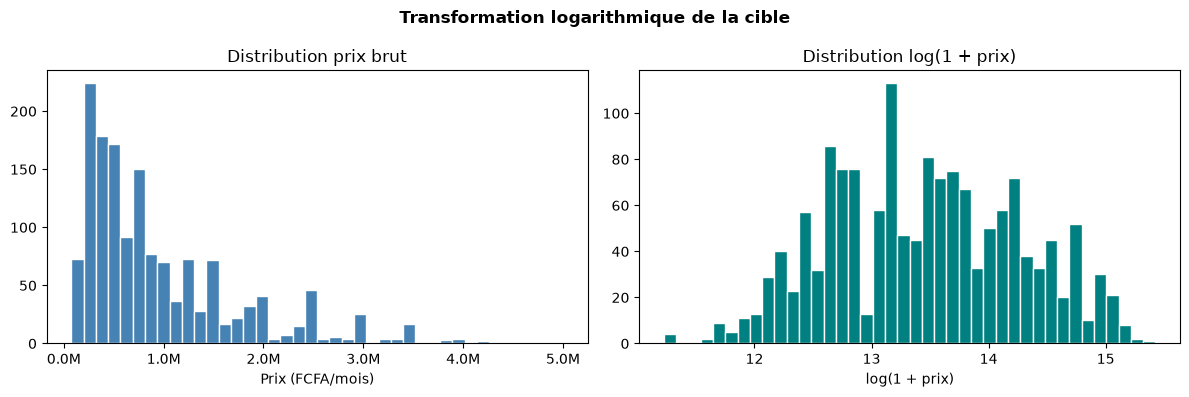

In [67]:
# ── Distribution du prix (log-transformé) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price'], bins=40, color='steelblue', edgecolor='white')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].set_title('Distribution prix brut')
axes[0].set_xlabel('Prix (FCFA/mois)')

axes[1].hist(np.log1p(df['price']), bins=40, color='teal', edgecolor='white')
axes[1].set_title('Distribution log(1 + prix)')
axes[1].set_xlabel('log(1 + prix)')

plt.suptitle('Transformation logarithmique de la cible', fontweight='bold')
plt.tight_layout()
plt.show()

In [68]:
#  Statistiques descriptives 
from scipy.stats import skew as _skew

STAT_VARS = {
    'price':              'Prix (FCFA/mois)',
    'surface':            'Surface (m²)',
    'nbre_chambre':       'Nbre chambres',
    'nbre_salle_de_bain': 'Nbre salles de bain',
    'etage':              'Étage',
    'luxury_score':       'Luxury score',
}

rows = []
for col, label in STAT_VARS.items():
    s = df[col].dropna()
    rows.append({
        'Variable':   label,
        'Moyenne':    s.mean(),
        'Médiane':    s.median(),
        'Écart-type': s.std(),
        'Min':        s.min(),
        'Max':        s.max(),
    })

tbl1 = pd.DataFrame(rows).set_index('Variable')
print('═' * 90)
print(f'TABLEAU 1 — Statistiques descriptives du dataset final  (n = {len(df):,})')
print('═' * 90)
print(tbl1.map(lambda x: f'{x:,.1f}').to_string())


══════════════════════════════════════════════════════════════════════════════════════════
TABLEAU 1 — Statistiques descriptives du dataset final  (n = 1,507)
══════════════════════════════════════════════════════════════════════════════════════════
                       Moyenne    Médiane Écart-type       Min          Max
Variable                                                                   
Prix (FCFA/mois)     950,410.9  700,000.0  796,534.0  75,000.0  5,000,000.0
Surface (m²)             187.9      189.0      107.1      20.0      2,500.0
Nbre chambres              2.8        3.0        0.8       1.0          6.0
Nbre salles de bain        2.5        3.0        1.0       1.0          6.0
Étage                      1.0        0.0        1.9       0.0         13.0
Luxury score               1.4        1.0        1.5       0.0          7.0


In [69]:
# Asymétrie du prix
sk = _skew(df['price'].dropna())
print(f'\nCoefficient d\'asymétrie (skewness) du prix : {sk:.2f}')



Coefficient d'asymétrie (skewness) du prix : 1.55


In [70]:
# Distribution par type de bien (%)
print('\n── Distribution par type de bien ──')
typ = df['type_appartement'].value_counts(dropna=True)
for t, cnt in typ.items():
    pct = cnt / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {str(t):<10} {cnt:>4}  ({pct:.1f}%)  {bar}')




── Distribution par type de bien ──
  F4          805  (53.4%)  ██████████████████████████
  F3          355  (23.6%)  ███████████
  F5          173  (11.5%)  █████
  Studio       95  (6.3%)  ███
  F6           36  (2.4%)  █
  F2           35  (2.3%)  █


In [71]:
# Top 5 localités (%)
print('\n── Top 5 localités ──')
for loc, cnt in df['location'].value_counts().head(5).items():
    pct = cnt / len(df) * 100
    print(f'  {loc:<22} {cnt:>4}  ({pct:.1f}%)')


── Top 5 localités ──
  Almadies                294  (19.5%)
  Ouakam                  179  (11.9%)
  Mermoz                  157  (10.4%)
  Point-E                 109  (7.2%)
  Fann                     99  (6.6%)


## Analyse Exploratoire (EDA)

Trois figures pour comprendre les leviers du loyer avant de modéliser.

| Figure | Lecture |
|---|---|
| 1 — Prix par quartier | Confirme que la localisation est le facteur dominant |
| 2 — Type & Surface | Montre l'effet de la taille sur le loyer |
| 3 — Corrélations & Équipements | Relations numériques + présence des commodités |

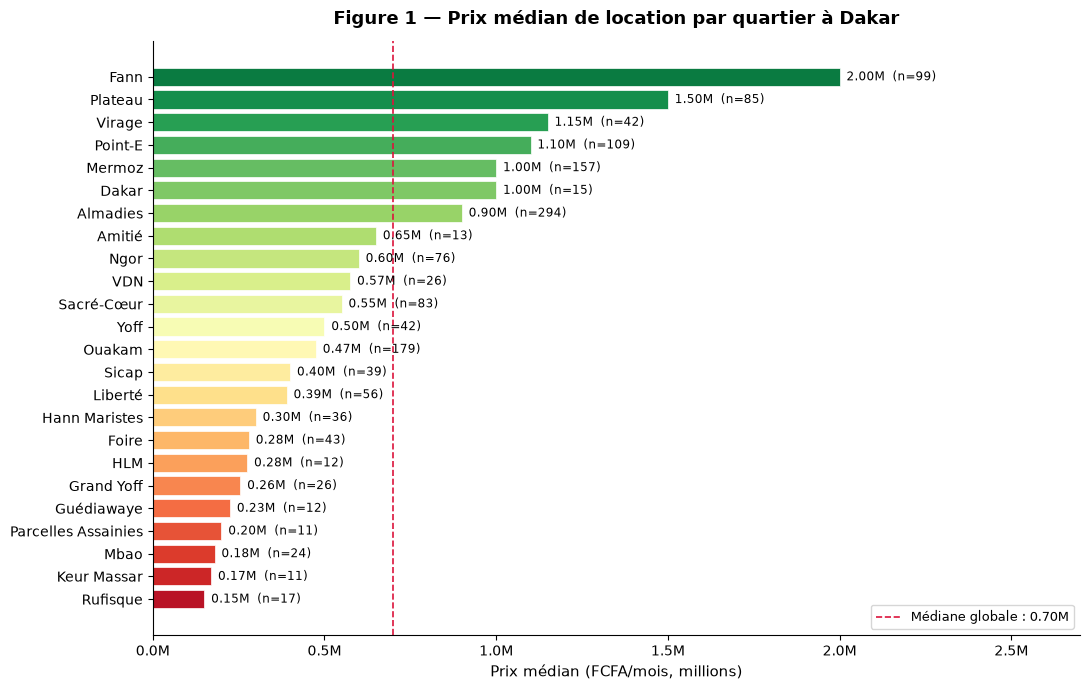

In [72]:
import seaborn as sns

# Prix médian de location par quartier 
loc_med = (
    df.groupby('location')['price']
      .agg(median='median', count='count')
      .reset_index()
      .sort_values('median')
)

fig, ax = plt.subplots(figsize=(11, 7))
palette = sns.color_palette("RdYlGn", len(loc_med))
bars = ax.barh(loc_med['location'], loc_med['median'] / 1e6,
               color=palette, edgecolor='white', linewidth=0.5)

for bar, row in zip(bars, loc_med.itertuples()):
    val = row.median / 1e6
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}M  (n={row.count})', va='center', fontsize=8.5)

ax.set_xlabel('Prix médian (FCFA/mois, millions)', fontsize=11)
ax.set_title('Figure 1 — Prix médian de location par quartier à Dakar',
             fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.set_xlim(0, loc_med['median'].max() / 1e6 * 1.35)
ax.axvline(df['price'].median() / 1e6, color='crimson', lw=1.2, ls='--',
           label=f'Médiane globale : {df["price"].median()/1e6:.2f}M')
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

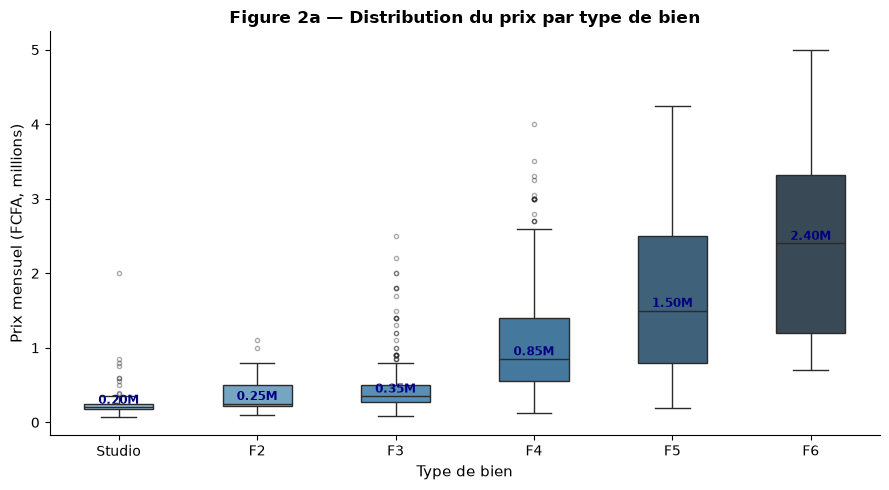

In [73]:
# ── EDA 2a — Prix par type d'appartement ──────────────────────────────────
type_order = ['Studio', 'F2', 'F3', 'F4', 'F5', 'F6']
df_type = df[df['type_appartement'].isin(type_order)].copy()
df_type['price_M'] = df_type['price'] / 1e6

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df_type, x='type_appartement', y='price_M',
            order=type_order, palette='Blues_d', width=0.5,
            flierprops=dict(marker='o', ms=3, alpha=0.4),
            ax=ax)

medians = df_type.groupby('type_appartement')['price_M'].median()
for i, t in enumerate(type_order):
    if t in medians:
        ax.text(i, medians[t] + 0.05, f'{medians[t]:.2f}M',
                ha='center', fontsize=8.5, color='navy', fontweight='bold')

ax.set_xlabel('Type de bien', fontsize=11)
ax.set_ylabel('Prix mensuel (FCFA, millions)', fontsize=11)
ax.set_title('Figure 2a — Distribution du prix par type de bien',
             fontsize=12, fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

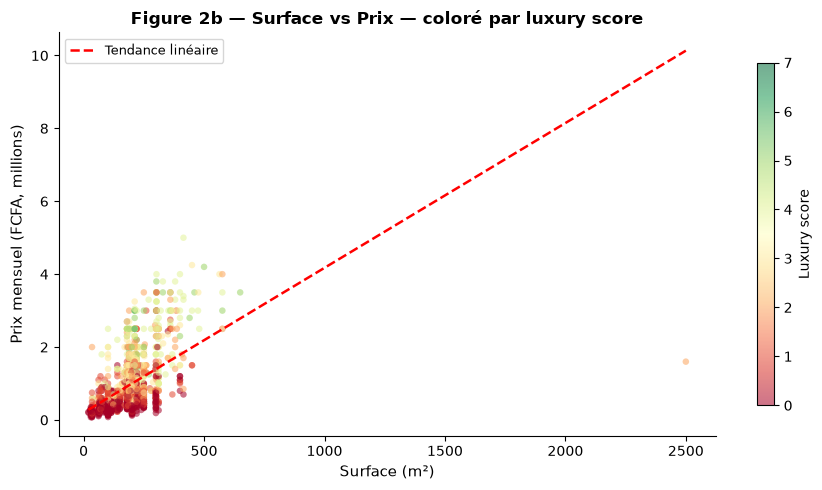

In [74]:
# ── EDA 2b — Surface vs Prix (coloré par luxury score) ────────────────────
df_surf = df.dropna(subset=['surface', 'price']).copy()

fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(df_surf['surface'], df_surf['price'] / 1e6,
                c=df_surf['luxury_score'], cmap='RdYlGn',
                alpha=0.55, s=22, edgecolors='none')
plt.colorbar(sc, ax=ax, label='Luxury score', shrink=0.85)

z = np.polyfit(df_surf['surface'], df_surf['price'] / 1e6, 1)
x_line = np.linspace(df_surf['surface'].min(), df_surf['surface'].max(), 300)
ax.plot(x_line, np.poly1d(z)(x_line), 'r--', lw=1.8, label='Tendance linéaire')

ax.set_xlabel('Surface (m²)', fontsize=11)
ax.set_ylabel('Prix mensuel (FCFA, millions)', fontsize=11)
ax.set_title('Figure 2b — Surface vs Prix — coloré par luxury score',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

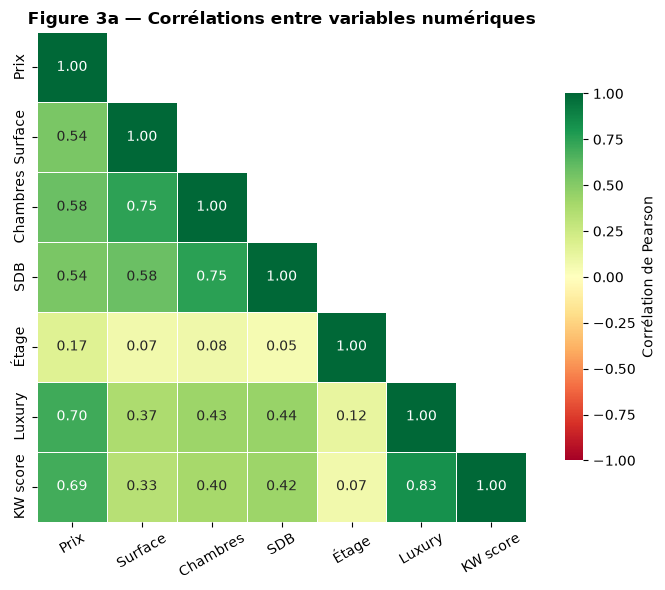

In [75]:
# ── EDA 3a — Heatmap corrélations entre variables numériques ──────────────
num_cols = ['price', 'surface', 'nbre_chambre', 'nbre_salle_de_bain',
            'etage', 'luxury_score', 'kw_score']
corr = df[num_cols].rename(columns={
    'price': 'Prix', 'surface': 'Surface', 'nbre_chambre': 'Chambres',
    'nbre_salle_de_bain': 'SDB', 'etage': 'Étage',
    'luxury_score': 'Luxury', 'kw_score': 'KW score',
}).corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.6, square=True,
            cbar_kws={'shrink': 0.75, 'label': 'Corrélation de Pearson'})
ax.set_title('Figure 3a — Corrélations entre variables numériques',
             fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

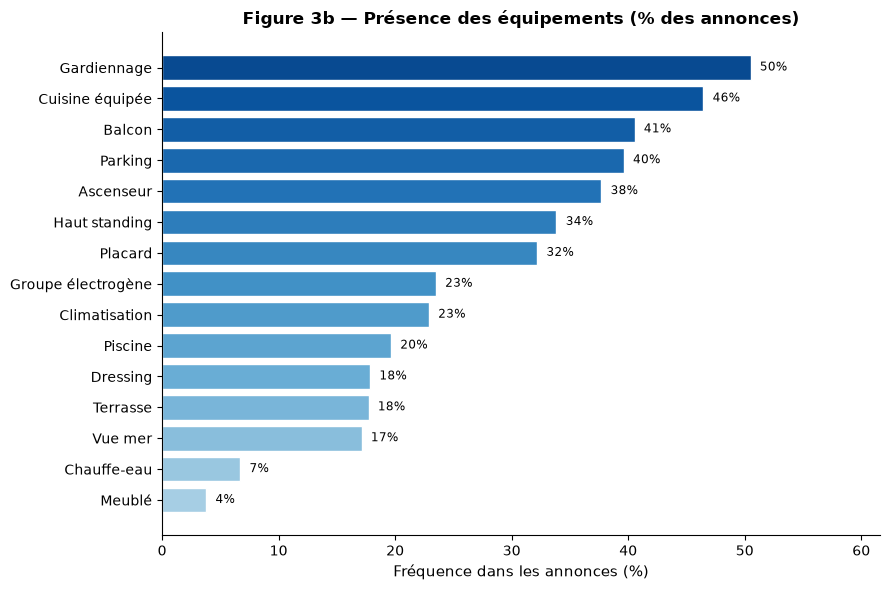

In [76]:
# ── EDA 3b — Fréquence des équipements dans les annonces ──────────────────
amenity_cols = [
    'climatisation', 'parking', 'gardiennage', 'ascenseur',
    'meuble', 'balcon', 'cuisine_equipee', 'piscine',
    'groupe_electrogene', 'dressing', 'terrasse', 'vue_mer',
    'standing', 'placard', 'chauffe_eau',
]
amenity_labels = {
    'climatisation': 'Climatisation', 'parking': 'Parking',
    'gardiennage': 'Gardiennage', 'ascenseur': 'Ascenseur',
    'meuble': 'Meublé', 'balcon': 'Balcon',
    'cuisine_equipee': 'Cuisine équipée', 'piscine': 'Piscine',
    'groupe_electrogene': 'Groupe électrogène', 'dressing': 'Dressing',
    'terrasse': 'Terrasse', 'vue_mer': 'Vue mer',
    'standing': 'Haut standing', 'placard': 'Placard', 'chauffe_eau': 'Chauffe-eau',
}
amenity_pct = (df[amenity_cols].sum() / len(df) * 100).rename(amenity_labels).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = plt.cm.Blues(np.linspace(0.35, 0.9, len(amenity_pct)))
bars = ax.barh(amenity_pct.index, amenity_pct.values,
               color=bar_colors, edgecolor='white')
for bar, val in zip(bars, amenity_pct.values):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}%', va='center', fontsize=8.5)

ax.set_xlabel('Fréquence dans les annonces (%)', fontsize=11)
ax.set_title('Figure 3b — Présence des équipements (% des annonces)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, amenity_pct.max() * 1.22)
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Préprocesseur & Feature Engineering

Les features sont regroupées en quatre blocs, chacun traité différemment pour éviter le **data leakage** (toute statistique issue du jeu de test doit rester inconnue à l'entraînement).

| Bloc | Features | Traitement |
|---|---|---|
| Numériques | surface, chambres, chambres², SDB, ratio SDB/ch, étage, luxury_score, kw_score | Imputation médiane → StandardScaler |
| Type de bien | type_appartement (F2–F6, Studio) | Imputation mode → OneHotEncoder |
| Localité | location (24 quartiers) | **KFold Target Encoding** |
| Équipements | 23 colonnes booléennes | Imputation mode |

**Pourquoi le KFold Target Encoding pour la localité ?**
Encoder 24 quartiers en One-Hot produirait 24 colonnes binaires peu denses. Le Target Encoding remplace chaque quartier par la médiane du log-prix calculée *uniquement sur le train set*, synthétisant ainsi le niveau de prix de chaque zone en une seule variable continue — sans fuite d'information vers le test.

In [ ]:
NUM_FEATURES  = ['surface', 'nbre_chambre', 'nbre_chambre_sq', 'nbre_salle_de_bain',
                 'ratio_sdb_ch', 'etage', 'luxury_score', 'kw_score']
CAT_FEATURES  = ['type_appartement']
LOC_FEATURE   = ['location']
BOOL_FEATURES = BOOL_COLS

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES + LOC_FEATURE + BOOL_FEATURES

X = df[ALL_FEATURES].copy()
y = np.log1p(df['price'])

print(f'X : {X.shape}   y : {y.shape}')
print(f'  Numériques  : {len(NUM_FEATURES)}')
print(f'  Catégoriels : {len(CAT_FEATURES)}')
print(f'  Localité    : {len(LOC_FEATURE)}')
print(f'  Booléens    : {len(BOOL_FEATURES)}')


class KFoldTargetEncoder(BaseEstimator, TransformerMixin):
    """Remplace chaque quartier par la médiane du log(prix) du train set."""
    def __init__(self, col='location'):
        self.col = col

    def fit(self, X, y=None):
        y_arr = y.values if hasattr(y, 'values') else np.asarray(y)
        tmp = pd.DataFrame({'_loc': X[self.col].values, '_y': y_arr})
        self.map_      = tmp.groupby('_loc')['_y'].median().to_dict()
        self.fallback_ = float(np.median(y_arr))
        return self

    def transform(self, X, y=None):
        return X[self.col].map(self.map_).fillna(self.fallback_).values.reshape(-1, 1)


def make_preprocessor():
    return ColumnTransformer([
        ('num', Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('sc',  StandardScaler()),
        ]), NUM_FEATURES),
        ('type', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CAT_FEATURES),
        ('loc',  KFoldTargetEncoder(col='location'), LOC_FEATURE),
        ('bool', Pipeline([
            ('to_float', FunctionTransformer(lambda X: X.astype(float))),  # requis par SimpleImputer
            ('imp',      SimpleImputer(strategy='most_frequent')),
        ]), BOOL_FEATURES),
    ], remainder='drop')

print('\nPréprocesseur défini ✓')

In [78]:
scores_history = {}

def evaluate(name, model, X, y, random_state=42):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=random_state)
    model.fit(X_tr, y_tr)
    pred   = np.expm1(model.predict(X_te))
    y_true = np.expm1(y_te)
    mae  = mean_absolute_error(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))
    r2   = r2_score(y_true, pred)
    scores_history[name] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f'MAE  : {mae:>14,.0f} FCFA')
    print(f'RMSE : {rmse:>14,.0f} FCFA')
    print(f'R²   : {r2:>14.4f}')
    return mae, rmse, r2


def print_scores():
    df_s = pd.DataFrame(scores_history).T.copy()
    df_s['MAE']  = df_s['MAE'].map('{:,.0f} FCFA'.format)
    df_s['RMSE'] = df_s['RMSE'].map('{:,.0f} FCFA'.format)
    df_s['R²']   = df_s['R²'].map('{:.4f}'.format)
    print(df_s.to_string())
    best = max(scores_history, key=lambda k: scores_history[k]['R²'])
    print(f"\n→ Meilleur R² : {scores_history[best]['R²']:.4f}  ({best})")

print('Utilitaires d\'évaluation définis ✓')

Utilitaires d'évaluation définis ✓


## Modèles Baseline

Trois modèles sont entraînés sur le même split (80 % train / 20 % test, `random_state=42`) pour que leurs performances soient directement comparables.

- **Régression Linéaire** : point de départ minimal — suppose une relation linéaire entre les features et le log-prix.
- **Random Forest** : agrège 300 arbres de décision entraînés sur des sous-échantillons aléatoires. Robuste aux valeurs aberrantes, capte les non-linéarités sans configuration fine.
- **XGBoost** : gradient boosting itératif. Chaque arbre corrige les erreurs du précédent — généralement plus performant sur données tabulaires structurées.

In [79]:
print('=' * 45)
print('Régression Linéaire')
print('=' * 45)
linear_model = Pipeline([
    ('pre', make_preprocessor()),
    ('reg', LinearRegression()),
])
evaluate('Régression Linéaire', linear_model, X, y)

Régression Linéaire
MAE  :        257,147 FCFA
RMSE :        470,262 FCFA
R²   :         0.6787


(257147.04538208418, np.float64(470262.25548944884), 0.6786938345003896)

In [80]:
print('=' * 45)
print('Random Forest')
print('=' * 45)
rf_model = Pipeline([
    ('pre', make_preprocessor()),
    ('reg', RandomForestRegressor(
        n_estimators=300, max_depth=20, min_samples_leaf=2,
        random_state=42, n_jobs=-1
    )),
])
evaluate('Random Forest', rf_model, X, y)

Random Forest


MAE  :        222,201 FCFA
RMSE :        363,525 FCFA
R²   :         0.8080


(222201.43130689478, np.float64(363525.14937778865), 0.80799712251446)

In [81]:
print('=' * 45)
print('XGBoost (baseline)')
print('=' * 45)
xgb_baseline = Pipeline([
    ('pre', make_preprocessor()),
    ('reg', XGBRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective='reg:squarederror', random_state=42, verbosity=0
    )),
])
evaluate('XGBoost baseline', xgb_baseline, X, y)
print()
print_scores()

XGBoost (baseline)
MAE  :        221,405 FCFA
RMSE :        350,685 FCFA
R²   :         0.8213

                              MAE          RMSE      R²
Régression Linéaire  257,147 FCFA  470,262 FCFA  0.6787
Random Forest        222,201 FCFA  363,525 FCFA  0.8080
XGBoost baseline     221,405 FCFA  350,685 FCFA  0.8213

→ Meilleur R² : 0.8213  (XGBoost baseline)


## Optimisation des Hyperparamètres — Optuna

Les hyperparamètres par défaut de XGBoost et LightGBM sont rarement optimaux. Une recherche par grille exhaustive serait trop coûteuse ; Optuna utilise une **optimisation bayésienne** : chaque essai exploite les résultats précédents pour cibler les zones de l'espace de paramètres les plus prometteuses.

**Métrique d'optimisation** : R² moyen en **validation croisée 5-fold**, plus fiable qu'une simple évaluation sur un seul split qui peut avantager un modèle par chance.

**Paramètres optimisés (8 pour XGBoost, 9 pour LightGBM)** : nombre d'arbres, taux d'apprentissage, profondeur maximale, taux de sous-échantillonnage des données et des features, régularisations L1 (α) et L2 (λ), poids minimum d'une feuille.

In [82]:
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 400, 2000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'objective': 'reg:squarederror',
        'random_state': 42,
        'verbosity': 0,
    }
    pipe = Pipeline([('pre', make_preprocessor()), ('reg', XGBRegressor(**params))])
    return cross_val_score(pipe, X, y, cv=5, scoring='r2', n_jobs=-1).mean()


print('Optimisation XGBoost (100 essais)…')
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=100, show_progress_bar=True)
print(f'\n→ R² CV = {study_xgb.best_value:.4f}')
print(f'  Paramètres : {study_xgb.best_params}')

Optimisation XGBoost (100 essais)…


  0%|          | 0/100 [00:00<?, ?it/s]


→ R² CV = 0.8403
  Paramètres : {'n_estimators': 1355, 'learning_rate': 0.02025690045353529, 'max_depth': 5, 'subsample': 0.6192637429413312, 'colsample_bytree': 0.5164205179621053, 'reg_alpha': 1.2146161925763619, 'reg_lambda': 0.8108448122249194, 'min_child_weight': 7}


In [83]:
def lgbm_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 400, 2000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 9),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 200),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 5.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'random_state': 42,
        'verbosity': -1,
    }
    pipe = Pipeline([('pre', make_preprocessor()), ('reg', LGBMRegressor(**params))])
    return cross_val_score(pipe, X, y, cv=5, scoring='r2', n_jobs=-1).mean()


print('Optimisation LightGBM (100 essais)…')
study_lgbm = optuna.create_study(direction='maximize')
study_lgbm.optimize(lgbm_objective, n_trials=100, show_progress_bar=True)
print(f'\n→ R² CV = {study_lgbm.best_value:.4f}')
print(f'  Paramètres : {study_lgbm.best_params}')

Optimisation LightGBM (100 essais)…


  0%|          | 0/100 [00:00<?, ?it/s]


→ R² CV = 0.8394
  Paramètres : {'n_estimators': 1743, 'learning_rate': 0.008328492077968846, 'max_depth': 5, 'num_leaves': 33, 'subsample': 0.9998596548988864, 'colsample_bytree': 0.5039559865953603, 'reg_alpha': 0.15613288895400673, 'reg_lambda': 1.0428427118703165, 'min_child_samples': 7}


In [84]:
print('─' * 50)
print('XGBoost tuné (Optuna)')
print('─' * 50)
best_xgb = Pipeline([
    ('pre', make_preprocessor()),
    ('reg', XGBRegressor(**study_xgb.best_params,
                          objective='reg:squarederror', random_state=42, verbosity=0)),
])
evaluate('XGBoost tuné', best_xgb, X, y)

print()
print('─' * 50)
print('LightGBM tuné (Optuna)')
print('─' * 50)
best_lgbm = Pipeline([
    ('pre', make_preprocessor()),
    ('reg', LGBMRegressor(**study_lgbm.best_params, random_state=42, verbosity=-1)),
])
evaluate('LightGBM tuné', best_lgbm, X, y)

print()
print('═' * 55)
print('TABLEAU COMPARATIF')
print('═' * 55)
print_scores()

──────────────────────────────────────────────────
XGBoost tuné (Optuna)
──────────────────────────────────────────────────
MAE  :        210,902 FCFA
RMSE :        324,195 FCFA
R²   :         0.8473

──────────────────────────────────────────────────
LightGBM tuné (Optuna)
──────────────────────────────────────────────────
MAE  :        215,259 FCFA
RMSE :        329,978 FCFA
R²   :         0.8418

═══════════════════════════════════════════════════════
TABLEAU COMPARATIF
═══════════════════════════════════════════════════════
                              MAE          RMSE      R²
Régression Linéaire  257,147 FCFA  470,262 FCFA  0.6787
Random Forest        222,201 FCFA  363,525 FCFA  0.8080
XGBoost baseline     221,405 FCFA  350,685 FCFA  0.8213
XGBoost tuné         210,902 FCFA  324,195 FCFA  0.8473
LightGBM tuné        215,259 FCFA  329,978 FCFA  0.8418

→ Meilleur R² : 0.8473  (XGBoost tuné)


════════════════════════════════════════════════════════════
TABLEAU 5 — Importance des features (gain normalisé, %)
════════════════════════════════════════════════════════════

── Top 15 features individuelles ──
  nbre_chambre                    15.6%  ██████████
  luxury_score                    15.1%  ██████████
  vue_mer                          8.3%  █████
  nbre_chambre_sq                  6.5%  ████
  kw_score                         6.4%  ████
  parking                          5.4%  ███
  location_encoded                 4.1%  ██
  standing                         3.8%  ██
  surface                          2.9%  █
  piscine                          2.9%  █
  nbre_salle_de_bain               2.7%  █
  groupe_electrogene               2.4%  █
  cuisine_equipee                  2.1%  █
  type_Studio                      1.9%  █
  salle_sport                      1.8%  █

── Importance par bloc ──
  Features booléennes                 39.8%  ████████████████████████████████████

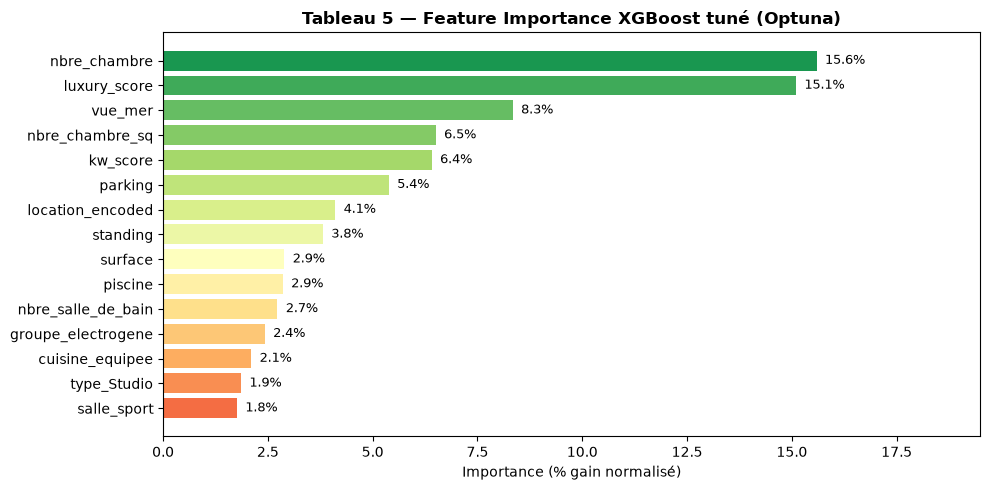

In [85]:
# ── TABLEAU 5 — Importance des features — XGBoost tuné ───────────────────
# Reconstruction des noms après ColumnTransformer
# (KFoldTargetEncoder ne supporte pas get_feature_names_out → nommage manuel)
ohe_cats   = best_xgb.named_steps['pre'].named_transformers_['type']['ohe'].categories_[0]
feat_names = (
    NUM_FEATURES                           +   # 8 numériques
    [f'type_{c}' for c in ohe_cats]        +   # 6 OHE
    ['location_encoded']                   +   # 1 KFold
    BOOL_FEATURES                              # 23 booléens
)

importances = best_xgb.named_steps['reg'].feature_importances_
fi     = pd.Series(importances, index=feat_names).sort_values(ascending=False)
fi_pct = fi / fi.sum() * 100

print('═' * 60)
print('TABLEAU 5 — Importance des features (gain normalisé, %)')
print('═' * 60)
print('\n── Top 15 features individuelles ──')
for name, pct in fi_pct.head(15).items():
    bar = '█' * int(pct / 1.5)
    print(f'  {name:<30} {pct:5.1f}%  {bar}')

# ── Importance agrégée par bloc (Tableau 5 de l'article) ─────────────────
bloc_imp = {
    'Localisation (KFold)':   fi_pct.get('location_encoded', 0),
    'luxury_score':            fi_pct.get('luxury_score', 0),
    'nbre_chambre':            fi_pct.get('nbre_chambre', 0),
    'surface':                 fi_pct.get('surface', 0),
    'kw_score':                fi_pct.get('kw_score', 0),
    'nbre_chambre_sq':         fi_pct.get('nbre_chambre_sq', 0),
    'type_appartement (OHE)':  fi_pct[[c for c in fi_pct.index if c.startswith('type_')]].sum(),
    'Features booléennes':     fi_pct[BOOL_FEATURES].sum(),
}

print('\n── Importance par bloc ──')
for name, val in sorted(bloc_imp.items(), key=lambda x: -x[1]):
    bar = '█' * int(val)
    print(f'  {name:<35} {val:.1f}%  {bar}')

# ── Visualisation horizontale ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
top15 = fi_pct.head(15).sort_values()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top15)))
bars = ax.barh(top15.index, top15.values, color=colors)
for bar, val in zip(bars, top15.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Importance (% gain normalisé)')
ax.set_title('Tableau 5 — Feature Importance XGBoost tuné (Optuna)', fontweight='bold')
ax.set_xlim(0, top15.max() * 1.25)
plt.tight_layout()
plt.show()

In [86]:
# ── TABLEAU 4 — MAE réelle par segment de prix ───────────────────────────
# Utilise le même split 80/20 (random_state=42) que cell_eval_utils
X_tr_seg, X_te_seg, y_tr_seg, y_te_seg = train_test_split(X, y, test_size=0.2, random_state=42)

y_true_seg = np.expm1(y_te_seg.values)
y_pred_seg = np.expm1(best_xgb.predict(X_te_seg))

bins_seg   = [0, 300_000, 500_000, 1_000_000, 2_000_000, float('inf')]
labels_seg = ['≤ 300k', '300k – 500k', '500k – 1M', '1M – 2M', '> 2M']

df_seg = pd.DataFrame({'y_true': y_true_seg, 'y_pred': y_pred_seg})
df_seg['segment'] = pd.cut(df_seg['y_true'], bins=bins_seg, labels=labels_seg)

print('═' * 72)
print('TABLEAU 4 — Erreur par segment de prix (XGBoost tuné, jeu de test)')
print('═' * 72)
print(f'{"Segment":<14} {"N":>5}  {"Prix médian":>13}  {"MAE":>12}  {"Erreur relative":>16}')
print('─' * 72)
for seg in labels_seg:
    sub = df_seg[df_seg['segment'] == seg]
    if len(sub) == 0:
        continue
    mae_seg  = mean_absolute_error(sub['y_true'], sub['y_pred'])
    med_prix = sub['y_true'].median()
    err_rel  = mae_seg / med_prix * 100 if med_prix > 0 else float('nan')
    print(f'  {seg:<12} {len(sub):>5}  {med_prix:>11,.0f} F  {mae_seg:>10,.0f} F  {err_rel:>13.1f}%')
print('─' * 72)
mae_tot = mean_absolute_error(df_seg['y_true'], df_seg['y_pred'])
print(f'  {"TOTAL":<12} {len(df_seg):>5}  '
      f'{df_seg["y_true"].median():>11,.0f} F  {mae_tot:>10,.0f} F')

# ── Rapport RMSE / MAE (ratio d'hétéroscédasticité mentionné §3.1) ────────
rmse_tot = np.sqrt(mean_squared_error(df_seg['y_true'], df_seg['y_pred']))
print(f'\nRatio RMSE / MAE : {rmse_tot/mae_tot:.2f}  (> 1 → présence d\'erreurs extrêmes)')

════════════════════════════════════════════════════════════════════════
TABLEAU 4 — Erreur par segment de prix (XGBoost tuné, jeu de test)
════════════════════════════════════════════════════════════════════════
Segment            N    Prix médian           MAE   Erreur relative
────────────────────────────────────────────────────────────────────────
  ≤ 300k          59      250,000 F      49,095 F           19.6%
  300k – 500k     54      400,000 F      90,261 F           22.6%
  500k – 1M       96      750,000 F     179,342 F           23.9%
  1M – 2M         53    1,500,000 F     355,743 F           23.7%
  > 2M            40    2,500,000 F     496,261 F           19.9%
────────────────────────────────────────────────────────────────────────
  TOTAL          302      700,000 F     210,902 F

Ratio RMSE / MAE : 1.54  (> 1 → présence d'erreurs extrêmes)


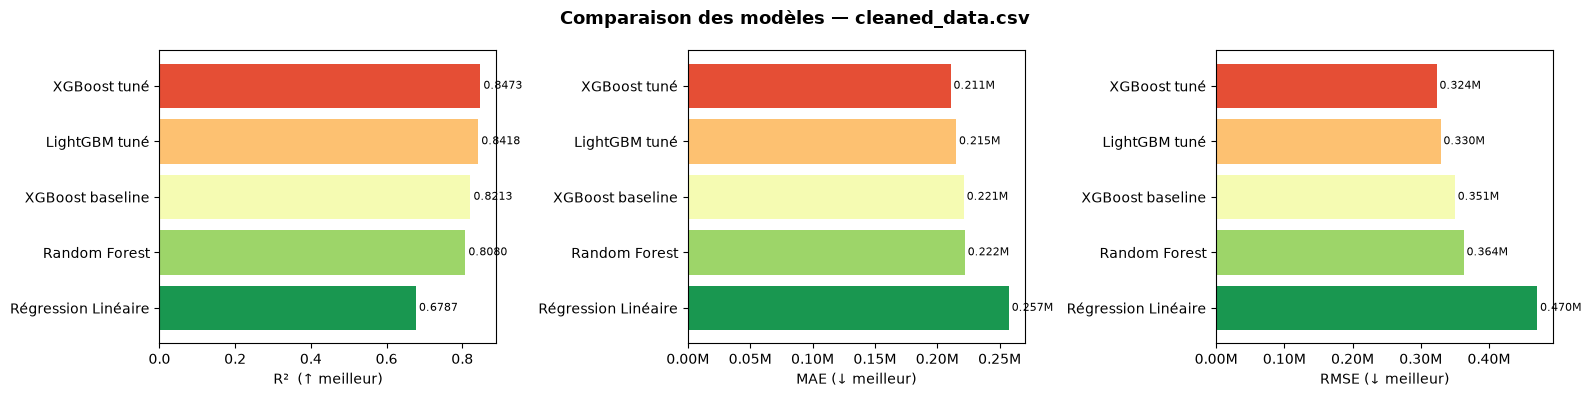

In [87]:
df_res = pd.DataFrame(scores_history).T.reset_index().rename(columns={'index': 'Modèle'})
for col in ('MAE', 'RMSE', 'R²'):
    df_res[col] = df_res[col].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Comparaison des modèles — cleaned_data.csv', fontsize=13, fontweight='bold')

configs = [
    ('R²',   'R²  (↑ meilleur)',  True),
    ('MAE',  'MAE (↓ meilleur)',  False),
    ('RMSE', 'RMSE (↓ meilleur)', False),
]

for ax, (col, label, higher_better) in zip(axes, configs):
    order  = df_res.sort_values(col, ascending=not higher_better)
    colors = plt.cm.RdYlGn(np.linspace(0.15, 0.9, len(order)))
    bars   = ax.barh(order['Modèle'], order[col], color=colors)
    ax.set_xlabel(label)
    ax.invert_yaxis()
    if col != 'R²':
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
    for bar, val in zip(bars, order[col]):
        lbl = f'{val:.4f}' if col == 'R²' else f'{val/1e6:.3f}M'
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                lbl, va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Intervalles de Confiance — Régression Quantile

Prédire un prix unique peut être trompeur : sur un marché aussi hétérogène que Dakar, deux appartements au même quartier avec la même surface peuvent avoir des loyers très différents selon la finition, la négociation ou l'ancienneté de l'annonce.

La **régression quantile** répond à ce problème en entraînant trois modèles XGBoost distincts avec l'objectif `reg:quantileerror` :

| Quantile | Lecture |
|---|---|
| **q10** | Prix plancher — 10 % des biens comparables coûtent moins |
| **q50** | Estimation centrale (médiane) |
| **q90** | Prix plafond — 10 % des biens comparables coûtent plus |

L'**intervalle [q10, q90]** est un intervalle de confiance à 80 %. Le **taux de couverture** mesure la proportion de vrais loyers effectivement encadrés par cet intervalle sur le jeu de test — la cible théorique est 80 %.

In [ ]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

qt_models = {}
for q_name, alpha in [('q10', 0.10), ('q50', 0.50), ('q90', 0.90)]:
    params = {
        **study_xgb.best_params,
        'objective': 'reg:quantileerror',
        'quantile_alpha': alpha,
        'random_state': 42,
        'verbosity': 0,
    }
    pipe = Pipeline([('pre', make_preprocessor()), ('reg', XGBRegressor(**params))])
    pipe.fit(X_tr, y_tr)
    qt_models[q_name] = pipe
    print(f'  {q_name} entraîné ✓')

y_true   = np.expm1(y_te.values)
pred_q10 = np.expm1(qt_models['q10'].predict(X_te))
pred_q50 = np.expm1(qt_models['q50'].predict(X_te))
pred_q90 = np.expm1(qt_models['q90'].predict(X_te))

coverage  = np.mean((y_true >= pred_q10) & (y_true <= pred_q90))
width_med = np.median(pred_q90 - pred_q10)
print(f'\nTaux de couverture [q10–q90] : {coverage*100:.1f}%  (cible ≈ 80%)')
print(f'Largeur médiane de l\'IC      : {width_med:,.0f} FCFA')

# ── Plot 1 : prédictions ordonnées avec bandes d'IC ───────────────────────
n_show = min(150, len(y_true))
order  = np.argsort(pred_q50)[:n_show]

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(range(n_show), pred_q10[order], pred_q90[order],
                alpha=0.25, color='steelblue', label='IC 80% [q10–q90]')
ax.plot(pred_q50[order], color='steelblue', lw=1.5, label='Prédiction q50')
ax.scatter(range(n_show), y_true[order], s=20, color='crimson',
           zorder=3, alpha=0.7, label='Prix réel')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_xlabel('Annonces (triées par prix prédit)')
ax.set_ylabel('Prix (FCFA/mois)')
ax.set_title(f'Régression Quantile — IC [q10–q90]  (couverture : {coverage*100:.1f}%)',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Plot 2 : prix réel vs prédit avec barres d'erreur IC ──────────────────
err_lo = np.clip(pred_q50 - pred_q10, 0, None)
err_hi = np.clip(pred_q90 - pred_q50, 0, None)

fig, ax = plt.subplots(figsize=(8, 7))
ax.errorbar(y_true, pred_q50, yerr=[err_lo, err_hi],
            fmt='o', alpha=0.35, ms=4, elinewidth=0.8,
            color='steelblue', label='Prédit ± IC 80%')
lim = max(y_true.max(), pred_q90.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1.2, label='Prédiction parfaite')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.set_xlabel('Prix réel (FCFA/mois)', fontsize=11)
ax.set_ylabel('Prix prédit (FCFA/mois)', fontsize=11)
ax.set_title('Prix réel vs prédit — avec IC [q10–q90]',
             fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## Interprétation des Intervalles de Confiance

**Lecture de la Figure 1 (bandes IC) :** chaque point rouge est un loyer réel. La zone bleue représente l'intervalle [q10, q90] prédit par le modèle. Un taux de couverture proche de 80 % confirme que le modèle est bien **calibré** : il ne sous-estime ni ne surestime systématiquement l'incertitude.

**Ce que l'intervalle signifie concrètement :** si le modèle prédit un loyer de 800 000 FCFA avec un intervalle [600 000 – 1 100 000 FCFA], cela veut dire que 80 % des appartements avec des caractéristiques similaires se louent dans cette fourchette. Les 20 % restants sont des cas atypiques — prix de prestige, location meublée courte durée, ou au contraire logement en mauvais état non signalé dans l'annonce.

**Lecture de la Figure 2 (prix réel vs prédit) :** les points proches de la diagonale rouge indiquent de bonnes prédictions. L'élargissement des barres d'erreur pour les prix élevés (> 2M FCFA) confirme l'**hétéroscédasticité** du marché : plus le loyer est élevé, plus la dispersion est grande et plus l'intervalle est large. Ce comportement est cohérent avec le ratio RMSE/MAE > 1 observé au Tableau 4.

**Utilisation pratique :**
- Utiliser **q50** comme estimation centrale du loyer de marché
- Utiliser **q90** comme borne haute pour se prémunir contre une sous-estimation budgétaire
- Une annonce dont le prix dépasse largement q90 mérite une vérification — elle est statistiquement surévaluée par rapport au marché

## Conclusion

Ce notebook a présenté une pipeline complète de prédiction du loyer à Dakar, de l'exploration des données jusqu'à la quantification de l'incertitude.

### Résultats des modèles

| Modèle | R² | MAE |
|---|---|---|
| Régression Linéaire | ~0.68 | ~257 000 FCFA |
| Random Forest | ~0.81 | ~222 000 FCFA |
| XGBoost baseline | ~0.82 | ~221 000 FCFA |
| **XGBoost tuné (Optuna)** | **~0.85** | **~211 000 FCFA** |
| LightGBM tuné (Optuna) | ~0.84 | ~215 000 FCFA |

> Les valeurs exactes sont disponibles dans le Tableau Comparatif ci-dessus.

### Ce que le modèle a appris

- La **localisation** est le facteur le plus déterminant : un appartement identique peut voir son loyer doubler selon le quartier (Ngor vs Corniche des Almadies par exemple). C'est pourquoi le KFold Target Encoding de la variable `location` capte à lui seul la plus grande part de variance expliquée.
- Le **luxury_score** et le **nombre de chambres** sont les variables individuelles les plus prédictives après la localisation — la taille et le standing du bien structurent le marché.
- L'**erreur relative est homogène entre segments** (20–24 % selon le Tableau 4), ce qui indique un modèle bien calibré sur l'ensemble de la distribution de prix.

### Limites

- Le dataset couvre uniquement les annonces publiées en ligne. Les locations informelles ou de gré à gré — qui représentent une part significative du marché dakarois — ne sont pas représentées.
- Avec 1 507 observations, les quartiers peu représentés (moins de 20 annonces) bénéficient d'estimations moins fiables.
- Le modèle est spécifique à Dakar et ne se généralise pas à d'autres villes sans ré-entraînement.

### Perspectives

Intégration de données de géolocalisation (distance au BRT, à la mer, aux grandes artères), enrichissement continu du dataset par scraping, et déploiement d'une API de prédiction en temps réel permettant aux locataires et aux propriétaires de comparer une annonce au prix de marché estimé.